# TEST corpus: neutron elastic

The Test corpus comprises directly-measured elastic scattering, analyzing power and integral cross section data that post-date the KD and CH89 publications, drawn entirely from EXFOR.

Neutron differential elastic scattering cross sections, stored in b/sr against CM scattering angle.

The subentries and scattering energies below are transcribed from the supplement's
tables into `spec/test_neutron_elastic.csv`. Every row must be accounted for: it either
produces data, or it is listed in `spec/known_missing.csv` with a reason. Uncertainties
are assigned by the supplement's preference rule (`nn_corpora.errors`), and the
corrections its Comments describe are applied from `nn_corpora.overrides`.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt

import pandas as pd

from nn_corpora import corpus, plotting, report, spec

pd.set_option("display.max_rows", 200)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## The specification

In [2]:
rows = spec.load_sector('test', 'neutron_elastic')
print(f"{len(rows)} rows, {len({r.subentry for r in rows if r.in_exfor})} distinct subentries")
pd.DataFrame([vars(r) for r in rows]).head(15)

196 rows, 42 distinct subentries


,corpus,sector,projectile,target_A,target_Z,target_label,energy_mev,energy_hi_mev,subentry,pointer,pdf_page
0,test,neutron_elastic,neutron,27,13,27Al,15.431,None,13903002,,26
1,test,neutron_elastic,neutron,28,14,28Si,15.430,None,14345002,,26
2,test,neutron_elastic,neutron,28,14,28Si,18.900,None,14345002,,26
3,test,neutron_elastic,neutron,32,16,32S,7.960,None,14345004,,26
4,test,neutron_elastic,neutron,32,16,32S,9.950,None,14345004,,26
5,test,neutron_elastic,neutron,32,16,32S,11.930,None,14345004,,26
6,test,neutron_elastic,neutron,32,16,32S,13.920,None,14345004,,26
7,test,neutron_elastic,neutron,32,16,32S,15.440,None,14345004,,26
8,test,neutron_elastic,neutron,32,16,32S,16.920,None,14345004,,26
9,test,neutron_elastic,neutron,32,16,32S,18.900,None,14345004,,26


## Retrieve and clean

`corpus.curate` retrieves each entry, matches measurements back to the rows that asked
for them, applies the documented corrections, and homogenises units and frames.

In [3]:
result = corpus.curate('test', 'neutron_elastic')
print(result.summary())

test/neutron_elastic
  spec rows              196
  ... marked absent      0
  ... resolved           195 / 196 (99.5%)
  measurements           192
  data points            4335
  EXFOR entries          19
  unresolved by category
    x4i3-parse-failure       1
  serialized             192 measurements, 4335 points
  dropped during cleaning
    22987005: only 1 scattering angle(s); too sparse to constrain an optical potential
    22987007: only 1 scattering angle(s); too sparse to constrain an optical potential
    31687002: only 2 scattering angle(s); too sparse to constrain an optical potential


## Rows that did not resolve

Every row listed here must appear in `spec/known_missing.csv`, or the write below will
fail. The categories are: `absent-from-exfor` (the supplement itself marks the row as
not locatable), `x4i3-parse-failure` (the entry is in EXFOR but x4i3 cannot read it),
`subentry-withdrawn` (EXFOR has renumbered or removed the subentry since the supplement
was written), `energy-not-found`, and `uncertainty-unresolved`.

In [4]:
print(report.unresolved_table(result.data))

natFe     8.170 32673002  [x4i3-parse-failure] parse failed: list index out of range


## Uncertainty audit

Data sets with missing uncertainties are dropped during munging, following the
supplement's removal of any data set lacking a necessary feature. This lists anything
that survived but still looks suspicious.

In [5]:
flags = plotting.check_uncertainties(result)
print("\n".join(flags) if flags else "every measurement carries uncertainties")

every measurement carries uncertainties


## Inspect

Outliers here are found by eye. A mistranscribed point shows up as a single datum an
order of magnitude away from its neighbours; a badly normalised data set shows up as a
whole curve offset from others at the same energy.

... 14 further targets not plotted


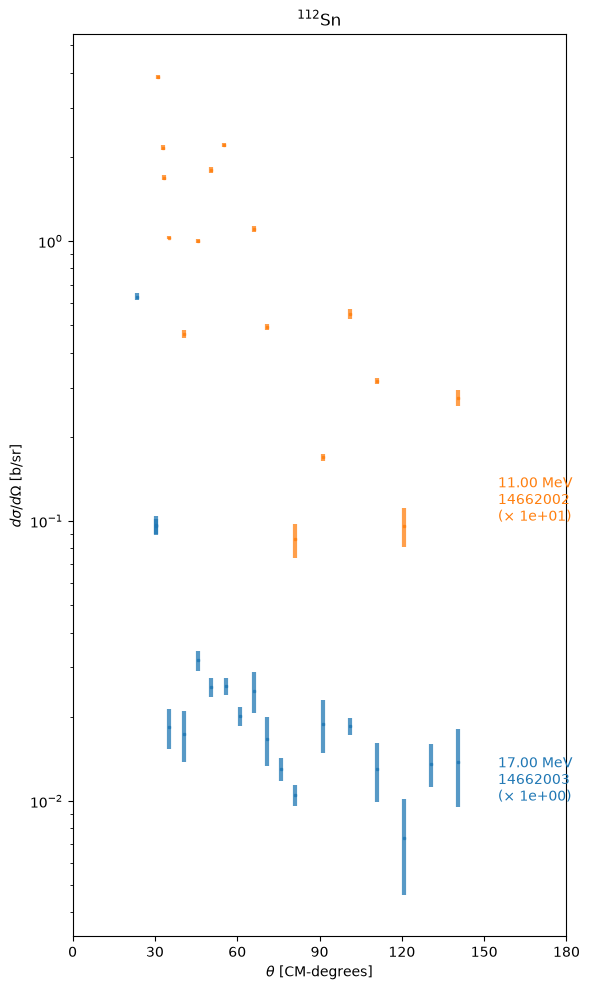

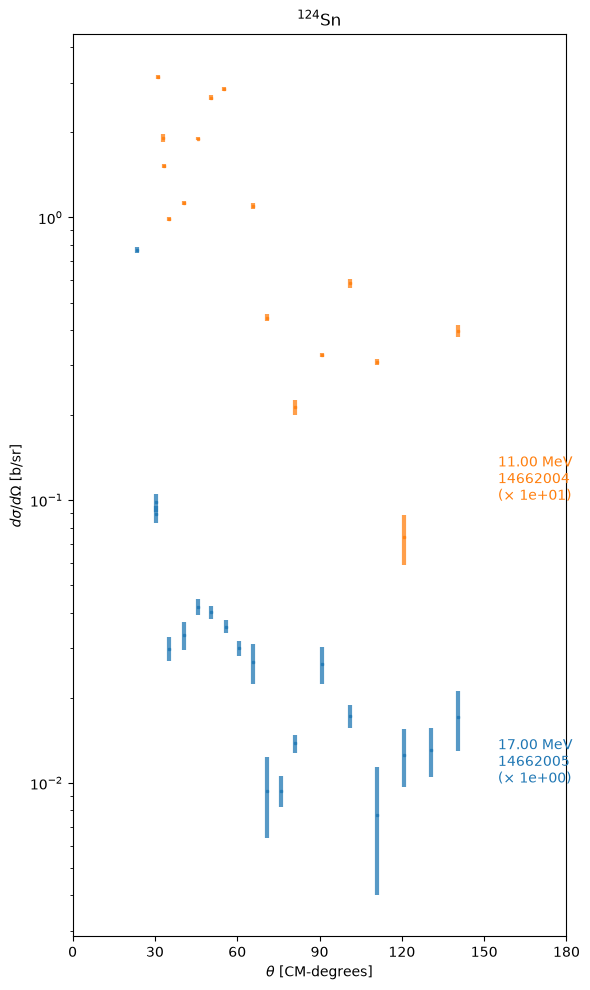

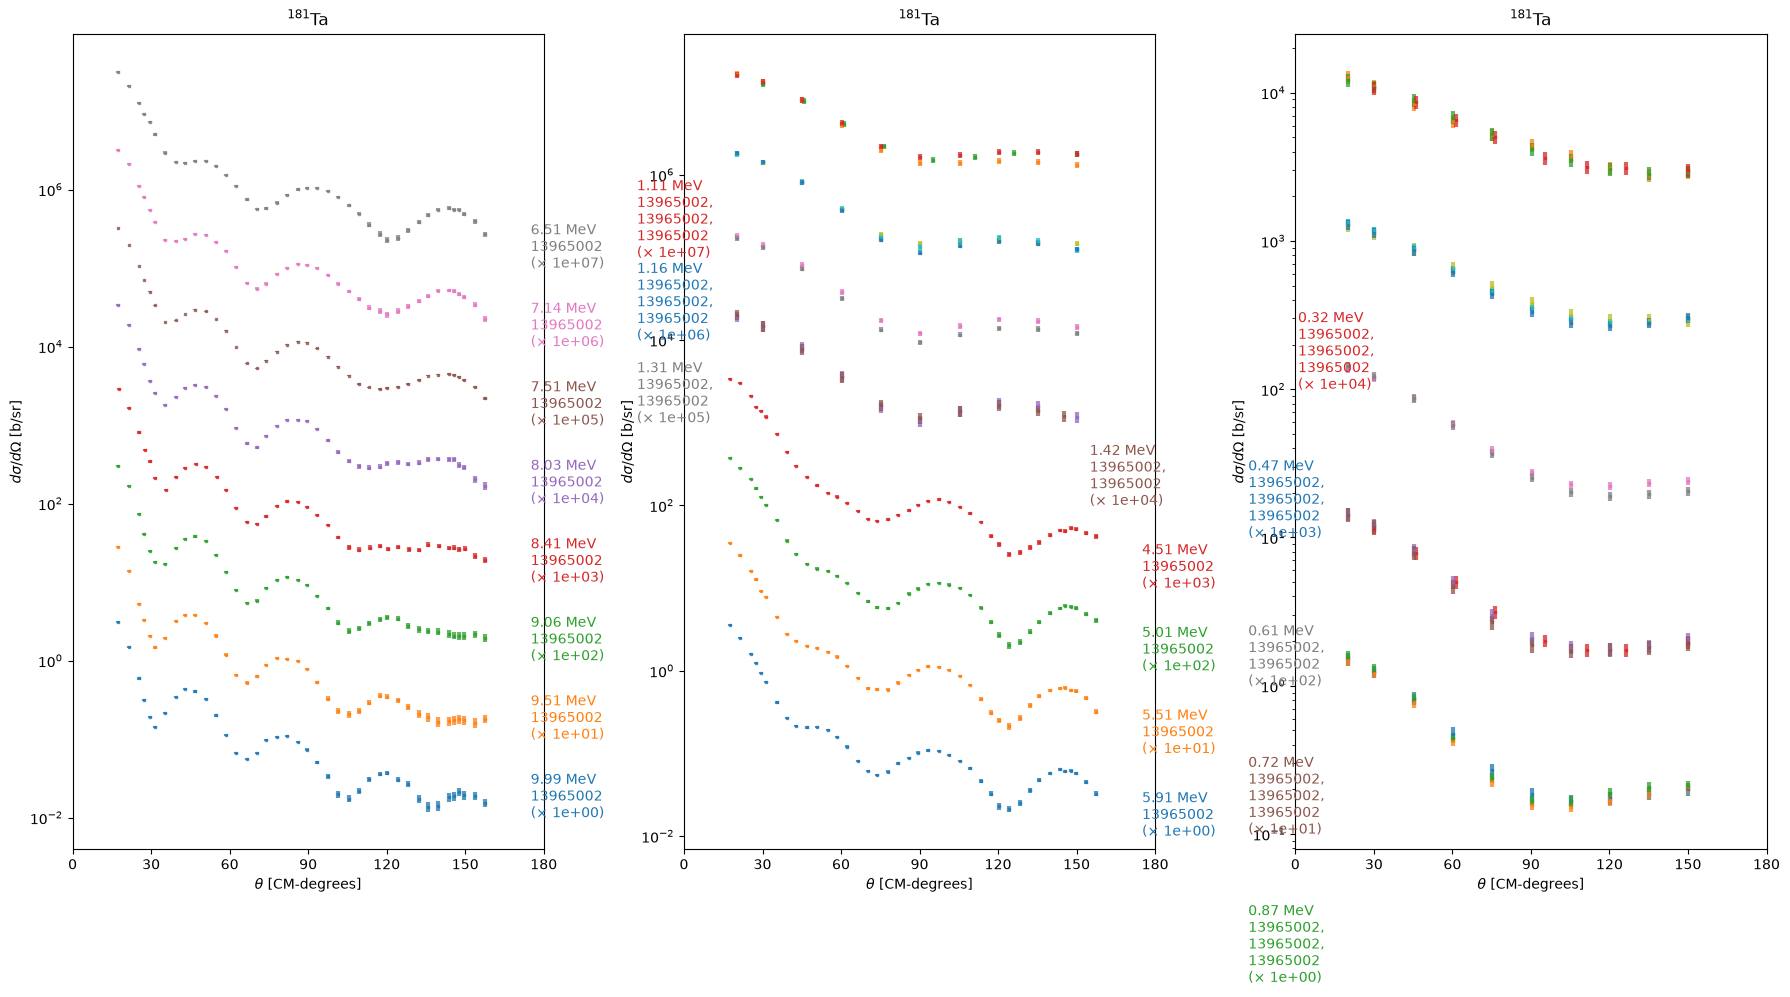

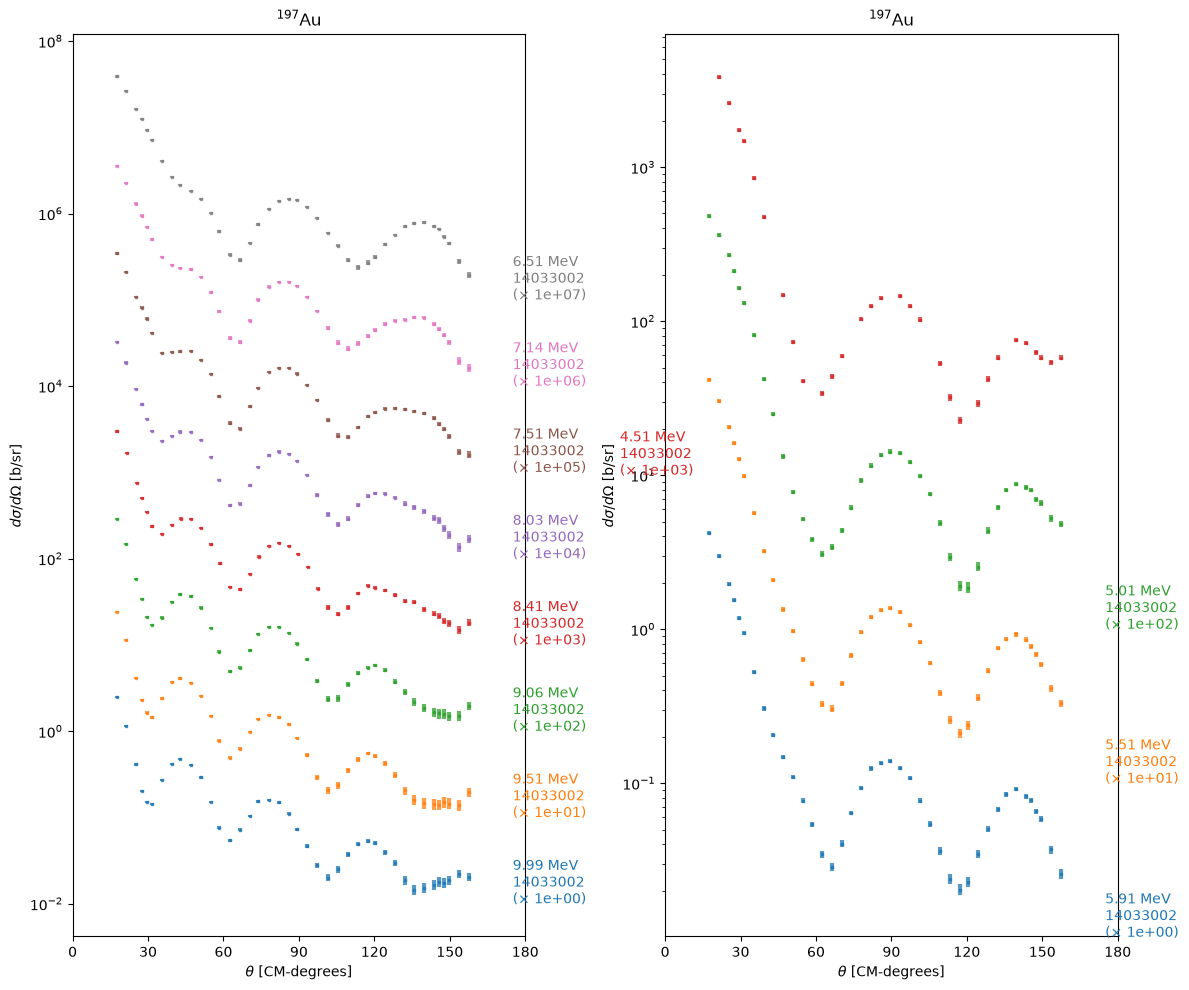

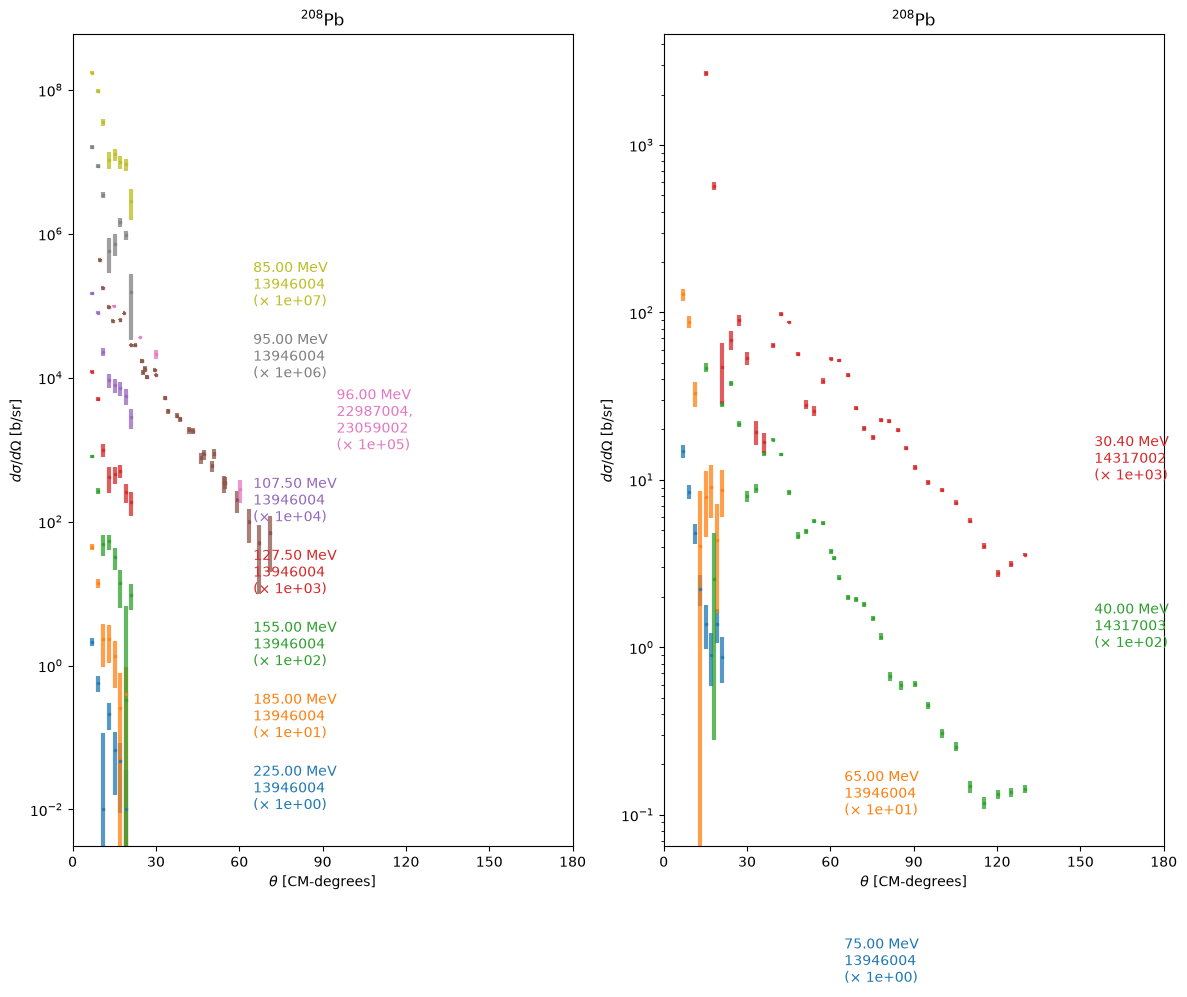

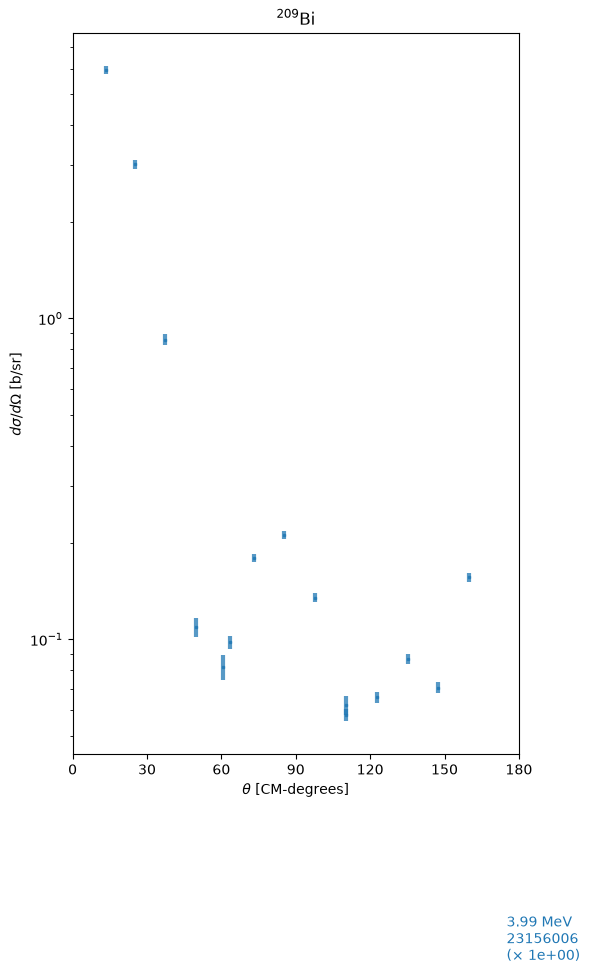

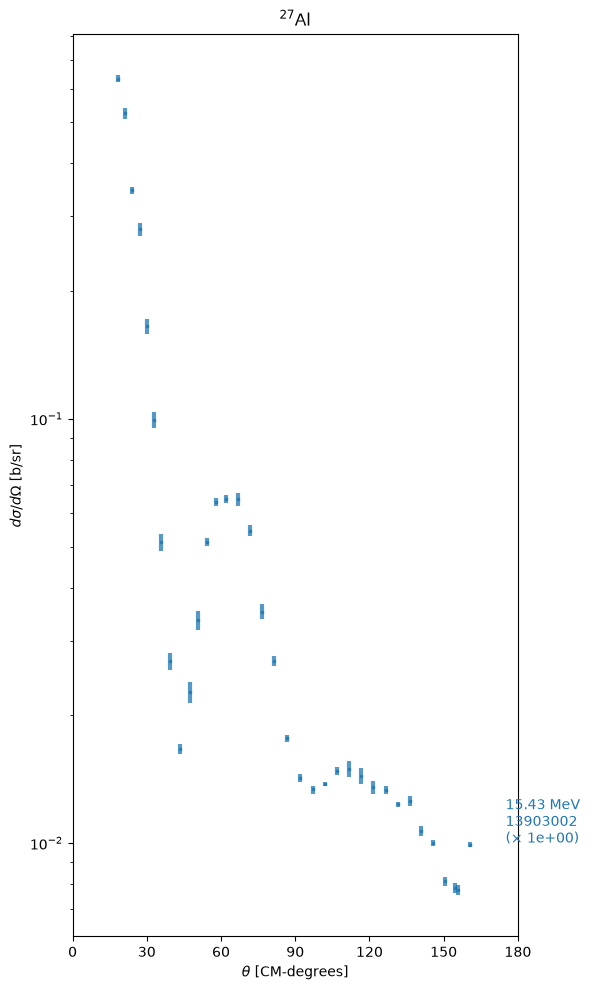

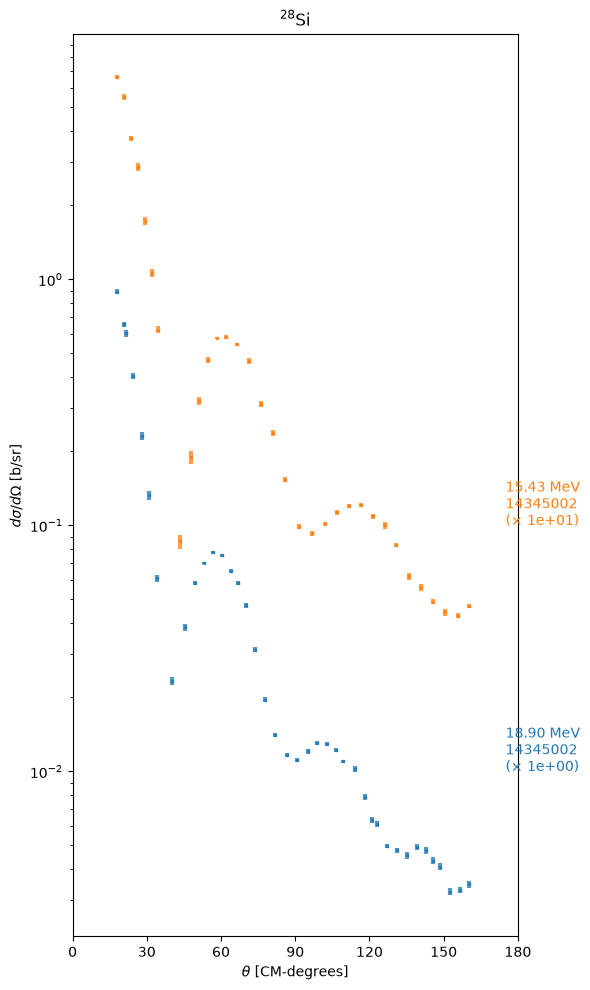

In [6]:
plotting.plot_sector(result, max_targets=8)
plt.show()

## Write

`corpus.write` re-checks coverage against the allowlist before writing, so a data set
that silently disappears from EXFOR fails here rather than passing unnoticed.

In [7]:
corpus.write(result)
print(f"wrote {len(result.records)} measurements to data/{result.corpus}/{result.sector}/")

wrote 192 measurements to data/test/neutron_elastic/
